# Reshaping the format of scenario data
- Three scenarios: High Bioenergy, Low Bioenergy, and Low Bioenergy + Limited Forestry
- Fill NaN with relevant values i.e. variable strings
- Adapt scenario data with D2.1 template
- Prepare the scenario data for plotting by summing up the demand for each feedstock type across biofuel types (i.e. liquid, solid, and gaseous)



In [1]:
import pandas as pd
from pandas_indexing import * # install through pip install pandas-indexing
import numpy as np
import pyam

# Plotting
import matplotlib.pyplot as plt

# System
from pathlib import Path

# Reshaping the dataframe

**Aggregating bioenergy demand from forestry activities**
What's considered as forestry activities:
- {sector}|{biofuel_type}|Harvestable Stemwood
- {sector}|{biofuel_type}|Primary Forestry Residues
- {sector}|{biofuel_type}|Secondary Forestry Residues

Summing up the values from these variables will give value for 
- {sector}|{biofuel_type}|Forestry Biomass

In [2]:
def reshape_scenario_df(
    file_name="FN_WP5_Feedstocks_High_Bioenergy_v2_shared.xlsx", scenario="BioEnerHigh"
):
    input_dir = Path.cwd() / ".." / "input_data"

    # Get a list of EU countries
    sheets_dict = pd.read_excel(f"{input_dir}/{file_name}", sheet_name=None)
    excluded_sheets = {"Cover", "info", "EL", "LX", "LA"}
    eu_countries = [k for k in sheets_dict.keys() if k not in excluded_sheets]

    BioEnerHigh_all = {}

    # Cleaning the dataframe to fit the data template previously agreed with IIASA
    # For each EU country
    for iso in eu_countries:
        BioEnerHigh = pd.read_excel(f"{input_dir}/{file_name}", sheet_name=iso)

        # Add country identifier
        BioEnerHigh.insert(loc=0, column="Region", value=iso)

        # Rename columns for better interpretation
        BioEnerHigh.rename(
            columns={"Unnamed: 1": "Bioefuel type", "Unnamed: 2": "Feedstock origins"},
            inplace=True,
        )

        # Step 1: Fill forward the values in `Sector` column
        BioEnerHigh["Primary Feedstock consumption by sector ktoe"] = BioEnerHigh[
            "Primary Feedstock consumption by sector ktoe"
        ].fillna(method="ffill")

        # Step 2: Fill forward the values in `Form of the energy` column
        BioEnerHigh["Bioefuel type"] = BioEnerHigh["Bioefuel type"].fillna(
            method="ffill"
        )

        # Step 3: Remove rows with NaN
        BioEnerHigh_clean = BioEnerHigh.dropna()

        # Remove leading spaces in "Bioefuel type"
        BioEnerHigh_clean["Bioefuel type"] = BioEnerHigh_clean[
            "Bioefuel type"
        ].str.strip()

        # Clean the variable names in "Feedstock origins"
        BioEnerHigh_clean["Feedstock origins"].replace(
            "Seconadry Forestry residues", "Secondary Forestry Residues", inplace=True
        )

        # Aggregating bioenergy demand from forestry activities
        sel_data = BioEnerHigh_clean.loc[
            (
                BioEnerHigh_clean["Feedstock origins"].isin(
                    [
                        "Harvestable Stemwood",
                        "Primary Forestry residues",
                        "Secondary Forestry Residues",
                    ]
                )
            )
        ]

        forestry = (
            sel_data.groupby(
                [
                    "Region",
                    "Primary Feedstock consumption by sector ktoe",
                    "Bioefuel type",
                ]
            )
            .sum()
            .reset_index()
        )

        if "Feedstock origins" in forestry.columns:
            forestry = forestry.drop(columns="Feedstock origins")
        
        forestry.insert(loc=3, column="Feedstock origins", value="Forestry Biomass")
        BioEnerHigh_clean = pd.concat([BioEnerHigh_clean, forestry])        

        # Standardizing the style of the strings in Feedstock origins column
        BioEnerHigh_clean["Feedstock origins"] = BioEnerHigh_clean["Feedstock origins"].apply(
            lambda x: x.title() if isinstance(x, str) else x
        )

        # Combine the strings in the three columns into one variable name
        var_strings = (
            BioEnerHigh_clean["Primary Feedstock consumption by sector ktoe"]
            + "|"
            + BioEnerHigh_clean["Bioefuel type"]
            + "|"
            + BioEnerHigh_clean["Feedstock origins"]
        )

        # Insert the strings in a Variable column
        BioEnerHigh_clean.insert(loc=1, column="Variable", value=var_strings)

        # Capitalize each letter of the strings in the Variable column
        BioEnerHigh_clean["Variable"] = BioEnerHigh_clean[
            "Variable"
        ].apply(lambda x: x.title() if isinstance(x, str) else x)

        # Drop the columns that are not necessary
        BioEnerHigh_clean = BioEnerHigh_clean.drop(
            [
                "Primary Feedstock consumption by sector ktoe",
                "Bioefuel type",
                "Feedstock origins",
            ],
            axis=1,
        )

        # Transform wide to long df
        BioEnerHigh_melt = pd.melt(BioEnerHigh_clean, id_vars=["Region", "Variable"])

        # Rename the columns createdfrom the wide to long transformation
        BioEnerHigh_melt.rename(
            columns={"variable": "Year", "value": "Value"}, inplace=True
        )

        # Create a column for Var_uid
        BioEnerHigh_melt.insert(loc=2, column="Var_uid", value=" ")

        # Add values to var_uid
        BioEnerHigh_melt["Var_uid"] = (
            BioEnerHigh_melt["Variable"].str.replace("|", "_").str.lower()
        )

        # Add unit
        BioEnerHigh_melt.insert(loc=4, column="Unit", value="ktoe")

        # Add the column for scenario
        BioEnerHigh_melt.insert(loc=3, column="Scenario", value=scenario)

        # Concat the clean dataframe for each country into one df
        BioEnerHigh_all[iso] = BioEnerHigh_melt

    result_df = pd.concat(BioEnerHigh_all.values())

    return eu_countries, result_df

In [3]:
eu_countries, BioEnerHigh = reshape_scenario_df("FN_WP5_Feedstocks_High_Bioenergy_v2_shared.xlsx", "BioEnerHigh")

/var/folders/kv/s7tk7p7x2cz5d7lmyrw8h6_h0000gn/T/ipykernel_9083/4193456818.py:28: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  BioEnerHigh["Primary Feedstock consumption by sector ktoe"] = BioEnerHigh[
/var/folders/kv/s7tk7p7x2cz5d7lmyrw8h6_h0000gn/T/ipykernel_9083/4193456818.py:33: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  BioEnerHigh["Bioefuel type"] = BioEnerHigh["Bioefuel type"].fillna(
/var/folders/kv/s7tk7p7x2cz5d7lmyrw8h6_h0000gn/T/ipykernel_9083/4193456818.py:41: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  BioEnerHigh_clean["Bioefuel type"] = BioEnerHigh_cl

In [4]:
eu_countries, BioEnerLow = reshape_scenario_df("FN_WP5_Feedstocks_Low_Bioenergy_v2_shared.xlsx", "BioEnerLow")

/var/folders/kv/s7tk7p7x2cz5d7lmyrw8h6_h0000gn/T/ipykernel_9083/4193456818.py:28: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  BioEnerHigh["Primary Feedstock consumption by sector ktoe"] = BioEnerHigh[
/var/folders/kv/s7tk7p7x2cz5d7lmyrw8h6_h0000gn/T/ipykernel_9083/4193456818.py:33: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  BioEnerHigh["Bioefuel type"] = BioEnerHigh["Bioefuel type"].fillna(
/var/folders/kv/s7tk7p7x2cz5d7lmyrw8h6_h0000gn/T/ipykernel_9083/4193456818.py:41: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  BioEnerHigh_clean["Bioefuel type"] = BioEnerHigh_cl

In [5]:
eu_countries, BioEnerLow_LimFor = reshape_scenario_df("FN_WP5_Feedstocks_Low_Bioenergy_LimFor_v2_shared.xlsx", "LimFor")

/var/folders/kv/s7tk7p7x2cz5d7lmyrw8h6_h0000gn/T/ipykernel_9083/4193456818.py:28: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  BioEnerHigh["Primary Feedstock consumption by sector ktoe"] = BioEnerHigh[
/var/folders/kv/s7tk7p7x2cz5d7lmyrw8h6_h0000gn/T/ipykernel_9083/4193456818.py:33: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  BioEnerHigh["Bioefuel type"] = BioEnerHigh["Bioefuel type"].fillna(
/var/folders/kv/s7tk7p7x2cz5d7lmyrw8h6_h0000gn/T/ipykernel_9083/4193456818.py:41: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  BioEnerHigh_clean["Bioefuel type"] = BioEnerHigh_cl

# Calculating total feedstock consumption across biofuel types

### Function

In [6]:
def total_feedstock_type(sel_sector, scenario_data):

    # Define the pattern for the wildcard search for the energy demand from a specific sector
    pattern = f"{sel_sector}\\|.*\\|"
    sector = scenario_data[scenario_data["Variable"].str.contains(pattern, regex=True)]

    # Template to store the total consumption from one feedstock type of all biofuel types
    sector_total = []

    # The types of the feedstock available in the master dataset
    feedstock_type = [
        "Food Crops", "Harvestable Stemwood", 
        "Primary Forestry Residues", "Secondary Forestry Residues",
        "Black Liquor", "Lignocelluosic Crops & Agricultural Residues",
        "Biomass Of Waste Origin", "Imported Wood",
        "Imported Oil", "Forestry Biomass"
    ]

    for year in sector["Year"].unique():

        # Subset the sectoral dataframe for a certain year
        household_y = sector.loc[sector["Year"] == year]

        # A template to store the sum of each feedstock type across liquid, solid, and gaseous biofuels
        feed_total = []

        for feed in feedstock_type:

            # Subset the dataset to include a certain feedstock type
            pattern = f"{sel_sector}\\|.*\\|{feed}"
            
            household_type_y = household_y[household_y["Variable"].str.contains(pattern, regex=True)]
            
            # Total food crops consumption in household sector
            household_type_y_val = household_type_y["Value"].sum(axis=0)

            # Create a new dataframe for the sum of each feedstock type
            reg_name = household_type_y["Region"].unique()[0]
            var_name = f"{sel_sector}|All Biofuels|{feed}"
            var_uid = var_name.replace("|", "_").lower()
            year_val = household_type_y["Year"].unique()[0]
            scenario_val = household_type_y["Scenario"].unique()[0]

            household_type_y_df = pd.DataFrame(
                {
                    "Region" : [reg_name],
                    "Variable" : [var_name],
                    "Var_uid" : [var_uid],
                    "Scenario" : [scenario_val],
                    "Year" : [year_val],
                    "Value" : [household_type_y_val]
                }
            )
            
            feed_total.append(household_type_y_df)

            feed_total_df = pd.concat(feed_total)
        
        sector_total.append(feed_total_df)

    sector_total_df = pd.concat(sector_total)

    return sector_total_df

## Household sector

### High Bioenergy scenario

In [7]:
calc_results = []

# List of all dataframes
bioener_dfs = [BioEnerHigh, BioEnerLow, BioEnerLow_LimFor]

for bioener_df in bioener_dfs:
    calc_template = {}  # Reset dictionary for each dataframe

    for iso in eu_countries:
        sel_df = bioener_df.loc[bioener_df["Region"] == iso]
        calc_template[iso] = total_feedstock_type(sel_sector="Household Demand", scenario_data=sel_df)
    
    # Store results in a list
    calc_results.append(pd.concat(calc_template.values()))

# Combine all results into one final dataframe
household_total_df = pd.concat(calc_results, ignore_index=True)

In [8]:
household_total_df.loc[
    (household_total_df["Scenario"] == "BioEnerHigh")
    & (household_total_df["Region"] == "AT")
    & (household_total_df["Year"] == 2030)
]

,Region,Variable,Var_uid,Scenario,Year,Value
110,AT,Household Demand|All Biofuels|Food Crops,household demand_all biofuels_food crops,BioEnerHigh,2030,3.241207
111,AT,Household Demand|All Biofuels|Harvestable Stem...,household demand_all biofuels_harvestable stem...,BioEnerHigh,2030,1431.168068
112,AT,Household Demand|All Biofuels|Primary Forestry...,household demand_all biofuels_primary forestry...,BioEnerHigh,2030,37.464881
113,AT,Household Demand|All Biofuels|Secondary Forest...,household demand_all biofuels_secondary forest...,BioEnerHigh,2030,16.153122
114,AT,Household Demand|All Biofuels|Black Liquor,household demand_all biofuels_black liquor,BioEnerHigh,2030,0.000000
115,AT,Household Demand|All Biofuels|Lignocelluosic C...,household demand_all biofuels_lignocelluosic c...,BioEnerHigh,2030,76.934444
116,AT,Household Demand|All Biofuels|Biomass Of Waste...,household demand_all biofuels_biomass of waste...,BioEnerHigh,2030,20.053179
117,AT,Household Demand|All Biofuels|Imported Wood,household demand_all biofuels_imported wood,BioEnerHigh,2030,13.314010
118,AT,Household Demand|All Biofuels|Imported Oil,household demand_all biofuels_imported oil,BioEnerHigh,2030,0.000000
119,AT,Household Demand|All Biofuels|Forestry Biomass,household demand_all biofuels_forestry biomass,BioEnerHigh,2030,1484.786072


## Transport sector

In [9]:
calc_results = []

# List of all dataframes
bioener_dfs = [BioEnerHigh, BioEnerLow, BioEnerLow_LimFor]

for bioener_df in bioener_dfs:
    calc_template = {}  # Reset dictionary for each dataframe

    for iso in eu_countries:
        sel_df = bioener_df.loc[bioener_df["Region"] == iso]
        calc_template[iso] = total_feedstock_type(sel_sector="Transport Demand", scenario_data=sel_df)
    
    # Store results in a list
    calc_results.append(pd.concat(calc_template.values()))

# Combine all results into one final dataframe
transport_total_df = pd.concat(calc_results, ignore_index=True)

## Industry sector

In [10]:
calc_results = []

# List of all dataframes
bioener_dfs = [BioEnerHigh, BioEnerLow, BioEnerLow_LimFor]

for bioener_df in bioener_dfs:
    calc_template = {}  # Reset dictionary for each dataframe

    for iso in eu_countries:
        sel_df = bioener_df.loc[bioener_df["Region"] == iso]
        calc_template[iso] = total_feedstock_type(sel_sector="Industry Demand", scenario_data=sel_df)
    
    # Store results in a list
    calc_results.append(pd.concat(calc_template.values()))

# Combine all results into one final dataframe
industry_total_df = pd.concat(calc_results, ignore_index=True)

In [11]:
industry_total_df.loc[
    (industry_total_df["Scenario"] == "BioEnerHigh")
    & (industry_total_df["Region"] == "EU27")
    & (industry_total_df["Year"] == 2050)
]

,Region,Variable,Var_uid,Scenario,Year,Value
70,EU27,Industry Demand|All Biofuels|Food Crops,industry demand_all biofuels_food crops,BioEnerHigh,2050,126.893262
71,EU27,Industry Demand|All Biofuels|Harvestable Stemwood,industry demand_all biofuels_harvestable stemwood,BioEnerHigh,2050,593.319346
72,EU27,Industry Demand|All Biofuels|Primary Forestry ...,industry demand_all biofuels_primary forestry ...,BioEnerHigh,2050,2449.898849
73,EU27,Industry Demand|All Biofuels|Secondary Forestr...,industry demand_all biofuels_secondary forestr...,BioEnerHigh,2050,3219.317794
74,EU27,Industry Demand|All Biofuels|Black Liquor,industry demand_all biofuels_black liquor,BioEnerHigh,2050,3702.384288
75,EU27,Industry Demand|All Biofuels|Lignocelluosic Cr...,industry demand_all biofuels_lignocelluosic cr...,BioEnerHigh,2050,11181.293141
76,EU27,Industry Demand|All Biofuels|Biomass Of Waste ...,industry demand_all biofuels_biomass of waste ...,BioEnerHigh,2050,5078.950407
77,EU27,Industry Demand|All Biofuels|Imported Wood,industry demand_all biofuels_imported wood,BioEnerHigh,2050,1222.477842
78,EU27,Industry Demand|All Biofuels|Imported Oil,industry demand_all biofuels_imported oil,BioEnerHigh,2050,0.000000
79,EU27,Industry Demand|All Biofuels|Forestry Biomass,industry demand_all biofuels_forestry biomass,BioEnerHigh,2050,6262.535989


## Electricity and district heat

In [12]:
calc_results = []

# List of all dataframes
bioener_dfs = [BioEnerHigh, BioEnerLow, BioEnerLow_LimFor]

for bioener_df in bioener_dfs:
    calc_template = {}  # Reset dictionary for each dataframe

    for iso in eu_countries:
        sel_df = bioener_df.loc[bioener_df["Region"] == iso]
        calc_template[iso] = total_feedstock_type(sel_sector="Electricity And District Heat Demand", scenario_data=sel_df)
    
    # Store results in a list
    calc_results.append(pd.concat(calc_template.values()))

# Combine all results into one final dataframe
elec_total_df = pd.concat(calc_results, ignore_index=True)

In [13]:
elec_total_df.loc[
    (elec_total_df["Scenario"] == "BioEnerHigh")
    & (elec_total_df["Region"] == "EU27")
    & (elec_total_df["Year"] == 2050)
]

,Region,Variable,Var_uid,Scenario,Year,Value
70,EU27,Electricity And District Heat Demand|All Biofu...,electricity and district heat demand_all biofu...,BioEnerHigh,2050,880.837436
71,EU27,Electricity And District Heat Demand|All Biofu...,electricity and district heat demand_all biofu...,BioEnerHigh,2050,4881.654389
72,EU27,Electricity And District Heat Demand|All Biofu...,electricity and district heat demand_all biofu...,BioEnerHigh,2050,12476.105640
73,EU27,Electricity And District Heat Demand|All Biofu...,electricity and district heat demand_all biofu...,BioEnerHigh,2050,17566.231483
74,EU27,Electricity And District Heat Demand|All Biofu...,electricity and district heat demand_all biofu...,BioEnerHigh,2050,9609.556997
75,EU27,Electricity And District Heat Demand|All Biofu...,electricity and district heat demand_all biofu...,BioEnerHigh,2050,62337.806326
76,EU27,Electricity And District Heat Demand|All Biofu...,electricity and district heat demand_all biofu...,BioEnerHigh,2050,27940.006942
77,EU27,Electricity And District Heat Demand|All Biofu...,electricity and district heat demand_all biofu...,BioEnerHigh,2050,6173.152519
78,EU27,Electricity And District Heat Demand|All Biofu...,electricity and district heat demand_all biofu...,BioEnerHigh,2050,0.000000
79,EU27,Electricity And District Heat Demand|All Biofu...,electricity and district heat demand_all biofu...,BioEnerHigh,2050,34923.991512


## Tertiary and other demand

In [14]:
calc_results = []

# List of all dataframes
bioener_dfs = [BioEnerHigh, BioEnerLow, BioEnerLow_LimFor]

for bioener_df in bioener_dfs:
    calc_template = {}  # Reset dictionary for each dataframe

    for iso in eu_countries:
        sel_df = bioener_df.loc[bioener_df["Region"] == iso]
        calc_template[iso] = total_feedstock_type(sel_sector="Tertiary And Other Demand", scenario_data=sel_df)
    
    # Store results in a list
    calc_results.append(pd.concat(calc_template.values()))

# Combine all results into one final dataframe
tertiary_total_df = pd.concat(calc_results, ignore_index=True)

In [15]:
tertiary_total_df.loc[
    (tertiary_total_df["Scenario"] == "BioEnerHigh")
    & (tertiary_total_df["Region"] == "EU27")
    & (tertiary_total_df["Year"] == 2050)
]

,Region,Variable,Var_uid,Scenario,Year,Value
70,EU27,Tertiary And Other Demand|All Biofuels|Food Crops,tertiary and other demand_all biofuels_food crops,BioEnerHigh,2050,172.231211
71,EU27,Tertiary And Other Demand|All Biofuels|Harvest...,tertiary and other demand_all biofuels_harvest...,BioEnerHigh,2050,2669.208830
72,EU27,Tertiary And Other Demand|All Biofuels|Primary...,tertiary and other demand_all biofuels_primary...,BioEnerHigh,2050,2503.045079
73,EU27,Tertiary And Other Demand|All Biofuels|Seconda...,tertiary and other demand_all biofuels_seconda...,BioEnerHigh,2050,3287.451262
74,EU27,Tertiary And Other Demand|All Biofuels|Black L...,tertiary and other demand_all biofuels_black l...,BioEnerHigh,2050,3.608030
75,EU27,Tertiary And Other Demand|All Biofuels|Lignoce...,tertiary and other demand_all biofuels_lignoce...,BioEnerHigh,2050,3408.265889
76,EU27,Tertiary And Other Demand|All Biofuels|Biomass...,tertiary and other demand_all biofuels_biomass...,BioEnerHigh,2050,3678.807379
77,EU27,Tertiary And Other Demand|All Biofuels|Importe...,tertiary and other demand_all biofuels_importe...,BioEnerHigh,2050,662.575000
78,EU27,Tertiary And Other Demand|All Biofuels|Importe...,tertiary and other demand_all biofuels_importe...,BioEnerHigh,2050,0.000000
79,EU27,Tertiary And Other Demand|All Biofuels|Forestr...,tertiary and other demand_all biofuels_forestr...,BioEnerHigh,2050,8459.705171


# Combining all datasets

In [16]:
all_scenario_data = pd.concat(
    [
        BioEnerHigh, BioEnerLow, BioEnerLow_LimFor, # Scenario data
        household_total_df, # Aggregated data for all fuel types in household sector
        transport_total_df,
        industry_total_df,
        elec_total_df,
        tertiary_total_df,
    ]
)

# Transforming the long dataframe to a pyam dataframe

In [17]:
# Fill-forward the empty rows in the "Unit" column
all_scenario_data["Unit"] = all_scenario_data["Unit"].fillna(method='ffill')

# Drop "Var_uid" column
all_scenario_copy = all_scenario_data.drop(["Var_uid"], axis=1)

# Transform from long to wide for the "Year" column
all_scenario_wide = all_scenario_copy.pivot_table(
    index=["Region", "Variable", "Scenario", "Unit"], 
    columns="Year", 
    values="Value"
).reset_index()

# Add a "Model" column
all_scenario_wide.insert(
    loc=0,
    column="Model",
    value="D5.1 Data"
)

# Transform to pyam
master_pyam = pyam.IamDataFrame(all_scenario_wide)

/var/folders/kv/s7tk7p7x2cz5d7lmyrw8h6_h0000gn/T/ipykernel_9083/1448052383.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  all_scenario_data["Unit"] = all_scenario_data["Unit"].fillna(method='ffill')
/Users/firzariany/opt/anaconda3/envs/firza_forest_geo/lib/python3.10/site-packages/pyam/utils.py:316: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  df.set_index(index + REQUIRED_COLS + extra_cols)


In [18]:
# Make a copy and convert to EJ
master_pyam_copy = master_pyam.convert_unit("ktoe", "EJ")

# Concat the dataset with ktoe and EJ
master_pyam_complete = pyam.concat([master_pyam, master_pyam_copy])

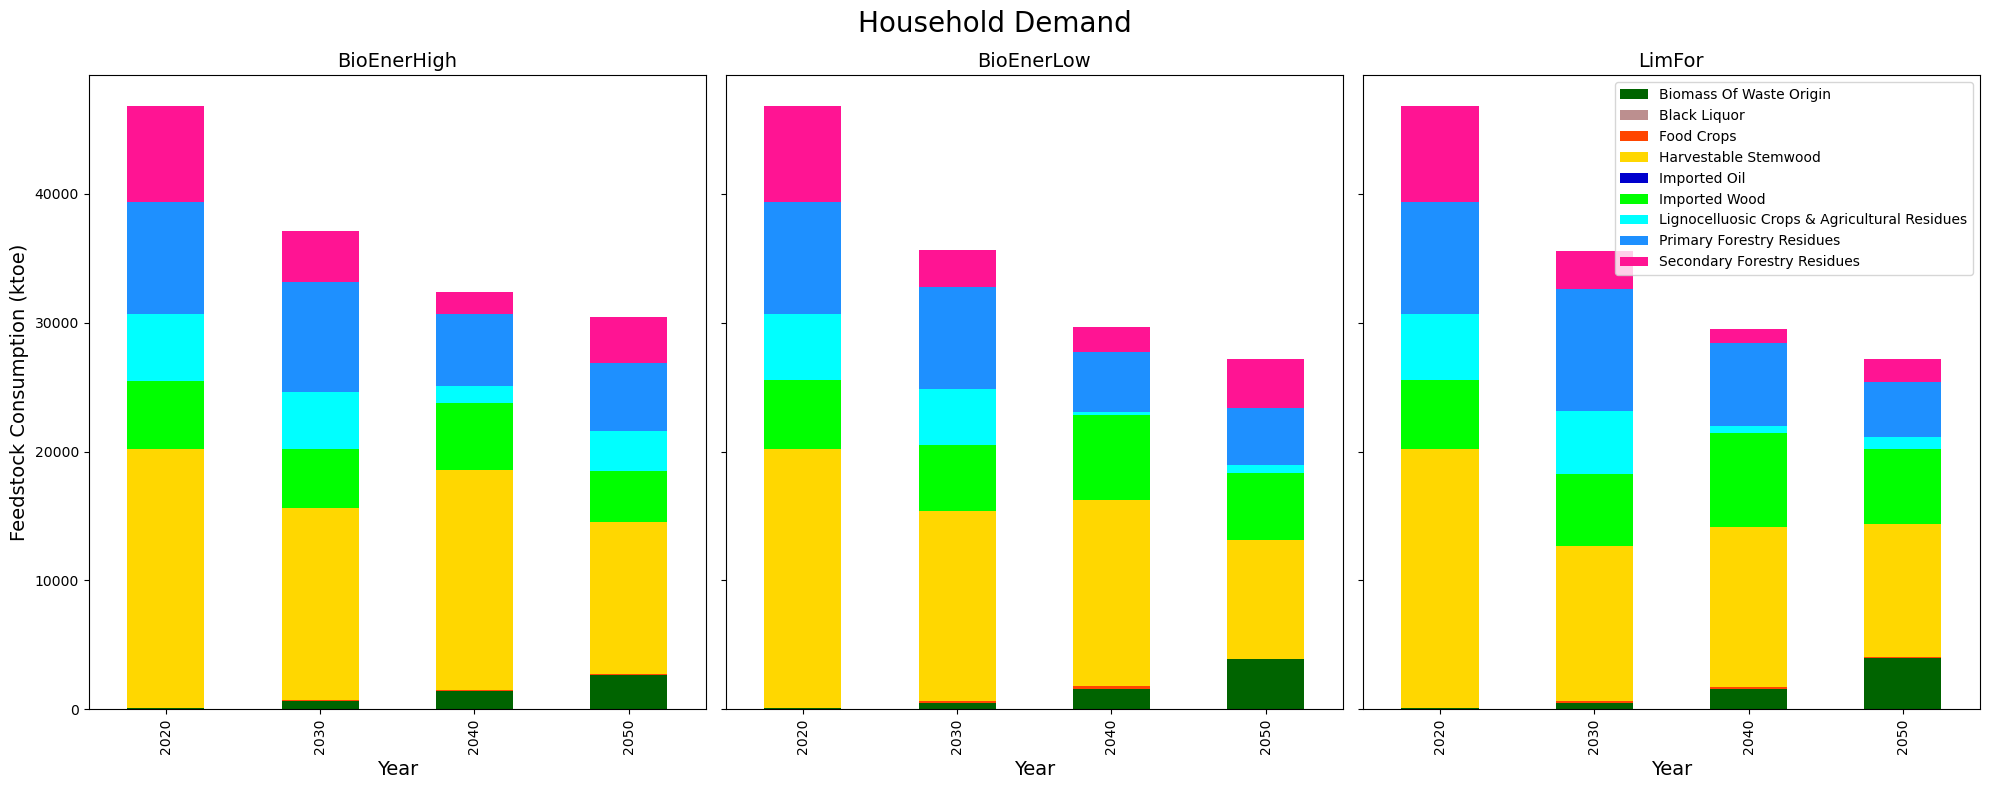

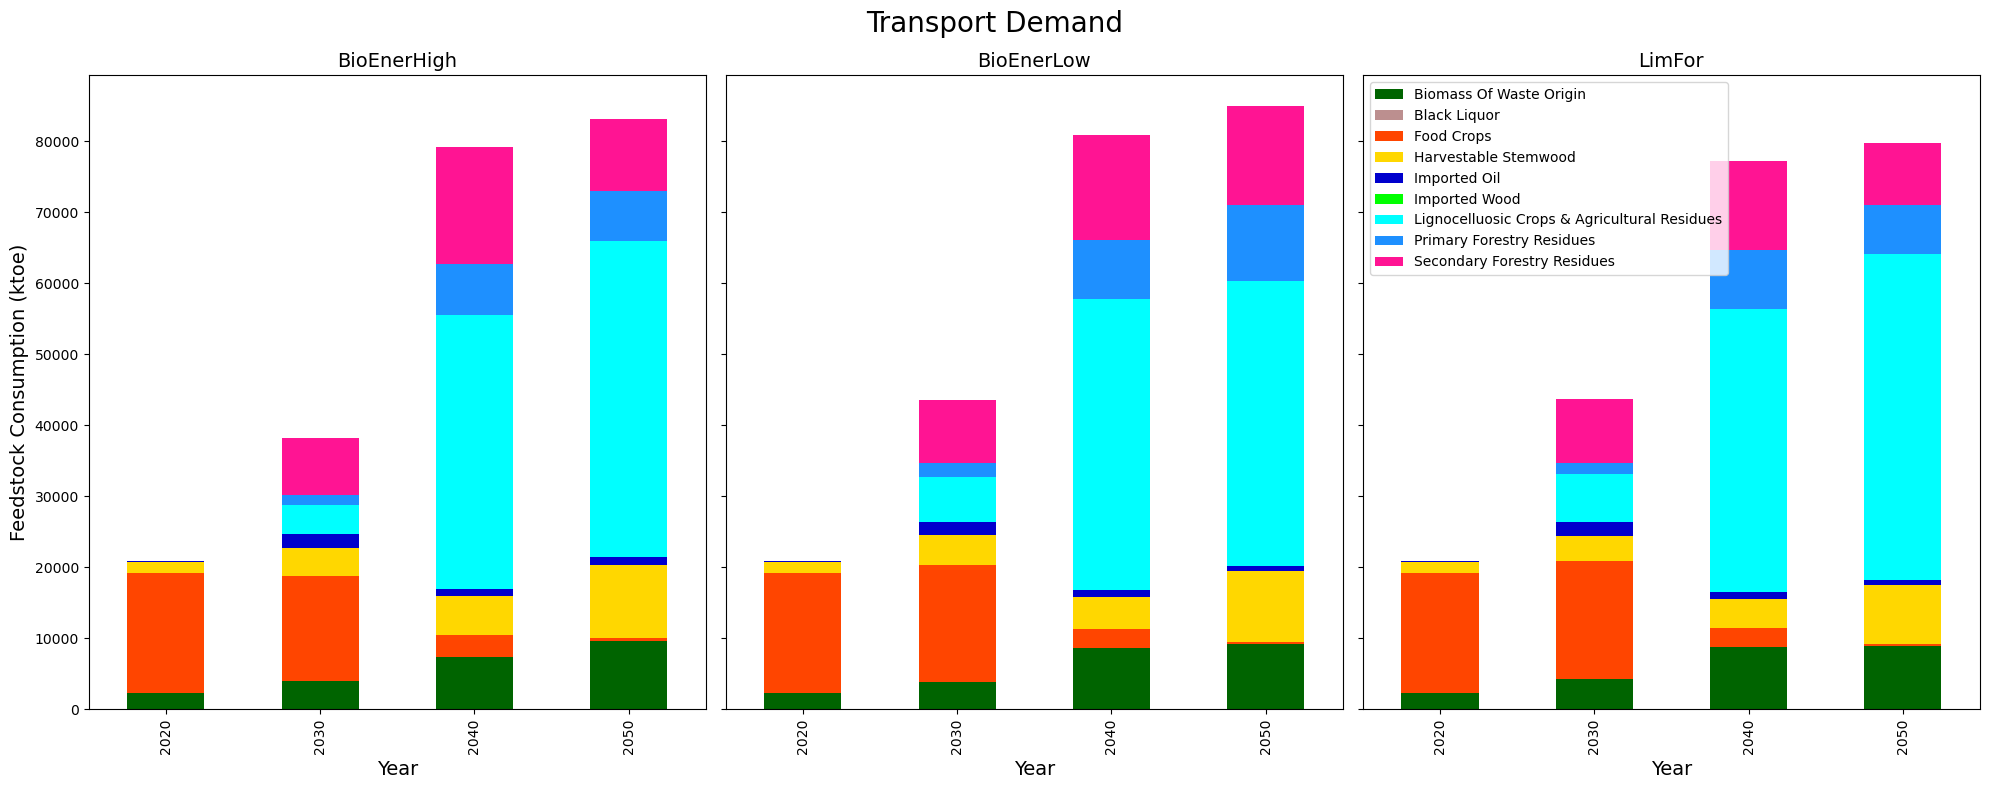

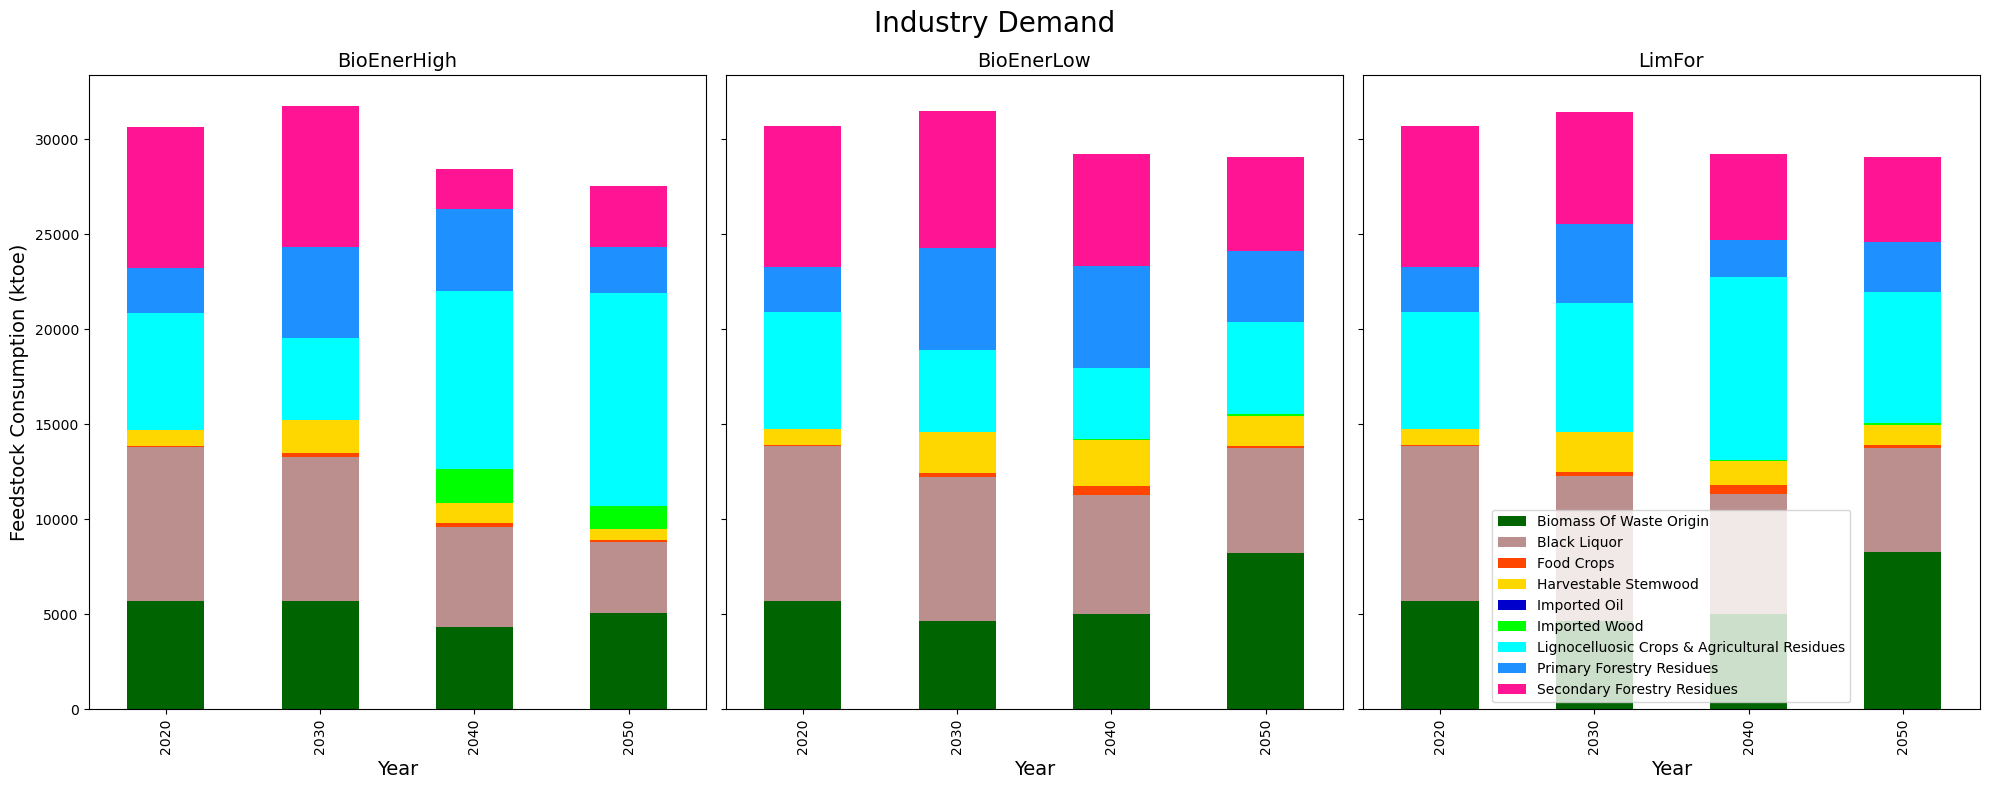

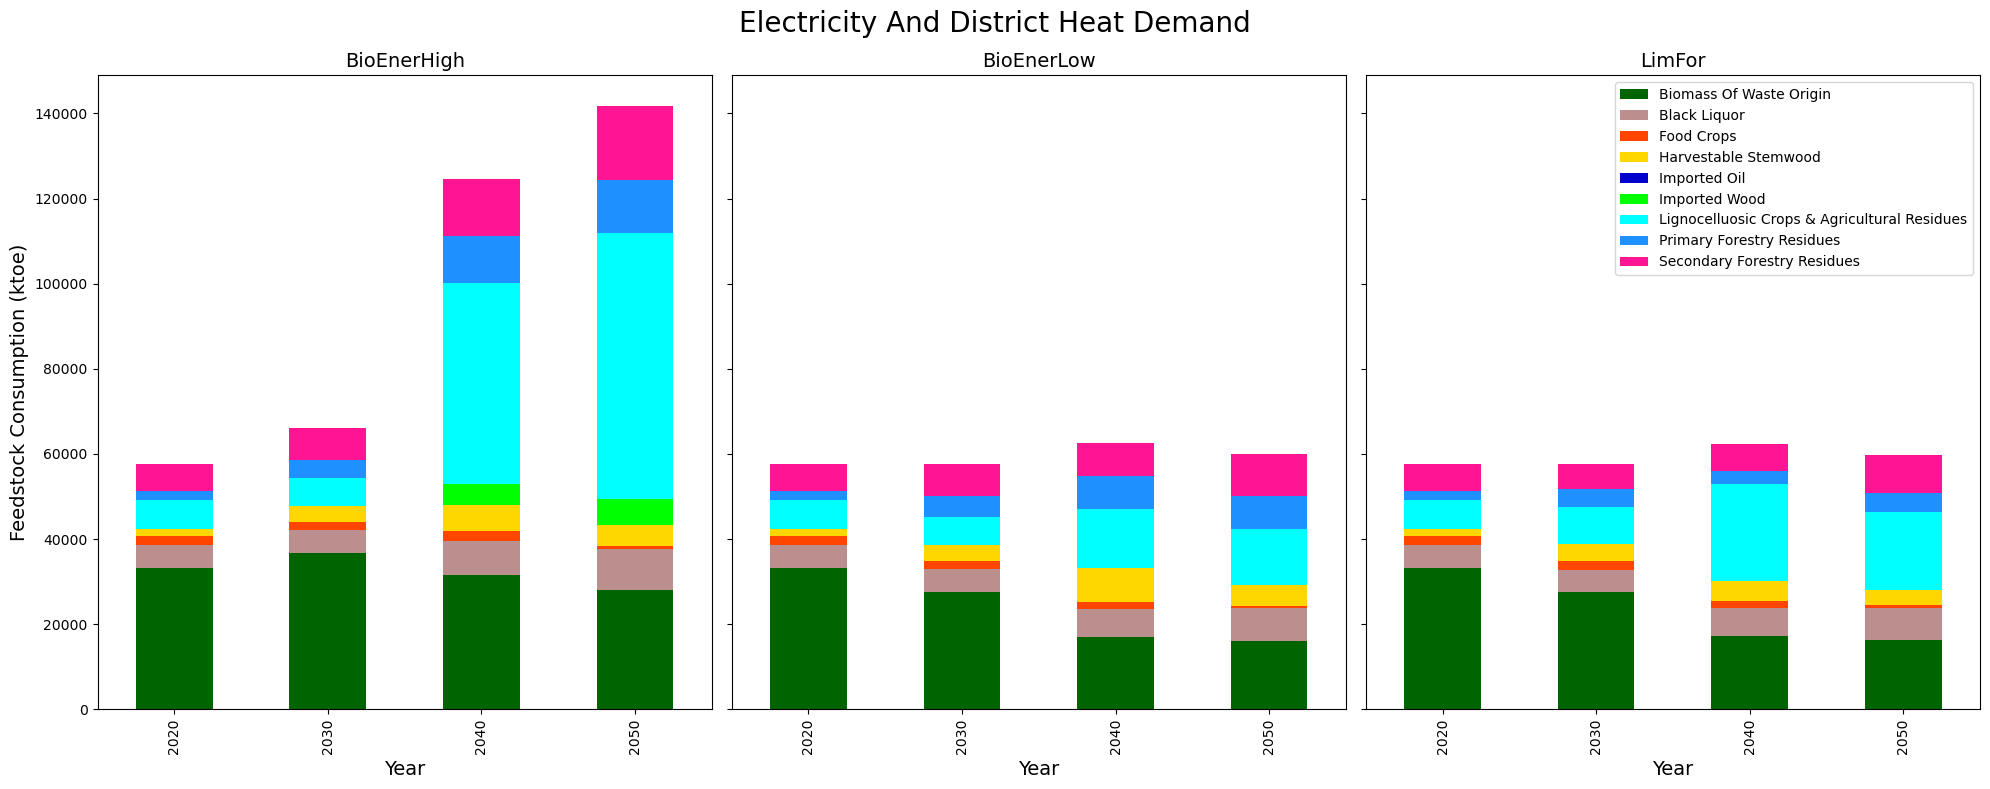

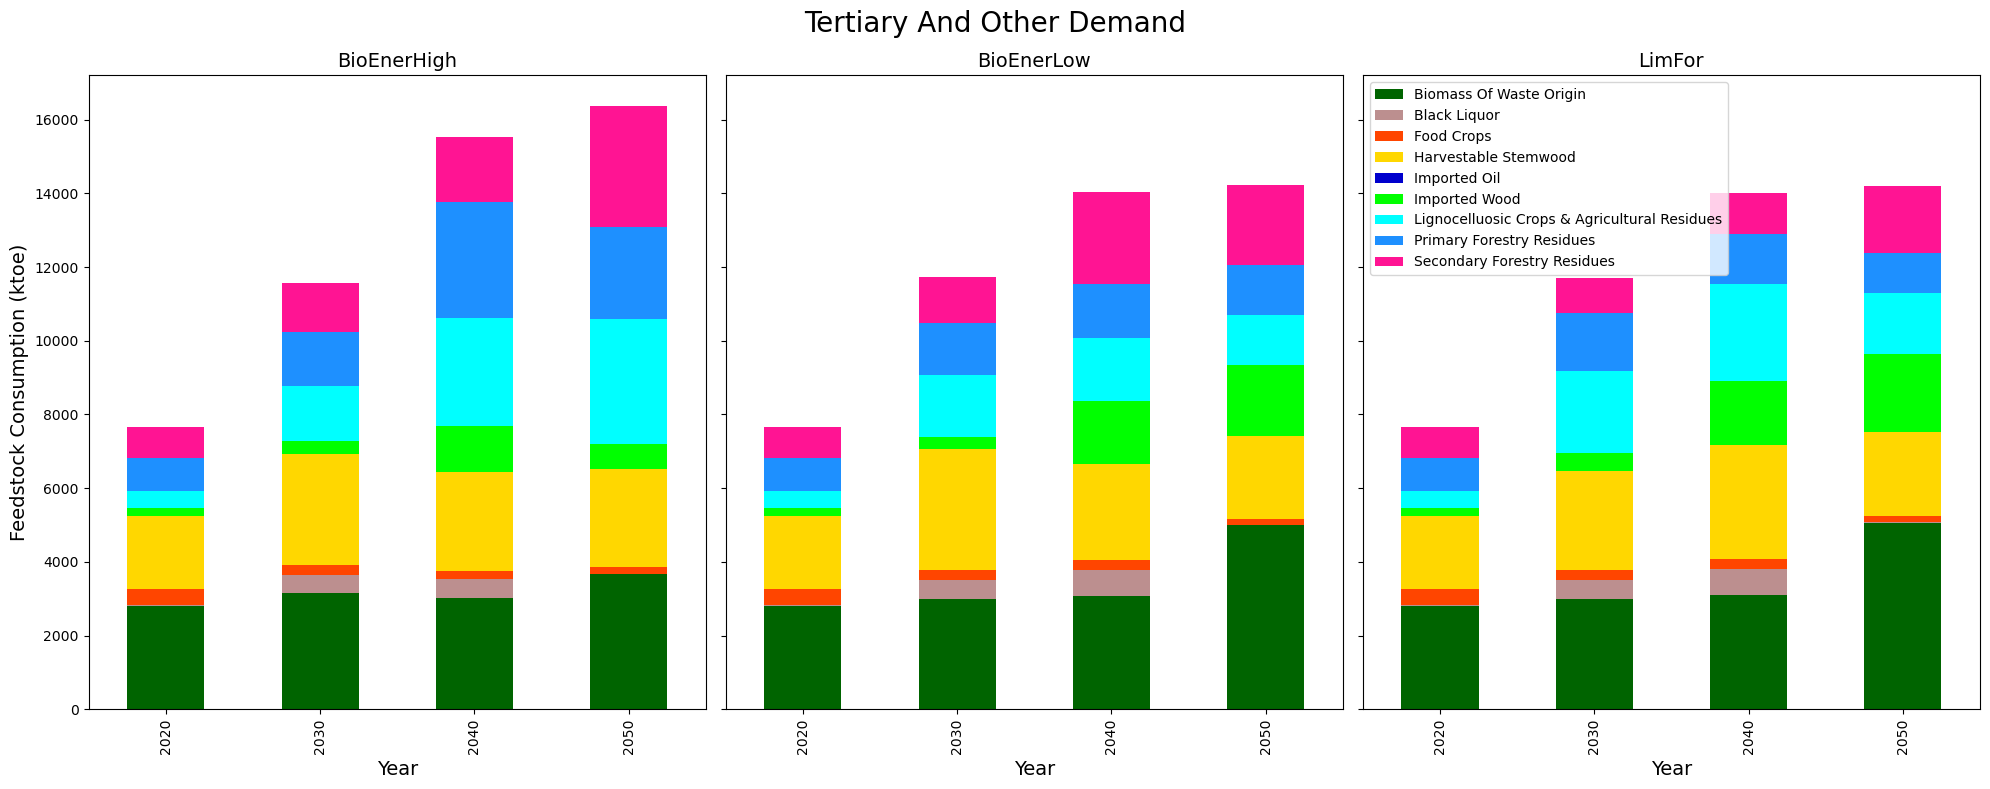

In [19]:
# Configure the color
var_color = {
    "Biomass Of Waste Origin": "#006400",
    "Black Liquor": "#bc8f8f",
    "Food Crops": "#ff4500",
    "Harvestable Stemwood": "#ffd700",
    "Imported Oil": "#0000cd",
    "Imported Wood": "#00ff00",
    "Lignocelluosic Crops & Agricultural Residues": "#00ffff",
    "Primary Forestry Residues": "#1e90ff",
    "Secondary Forestry Residues": "#ff1493",
}

pyam.run_control()["color"]["variable"] = var_color

# Plotting with Pyam stacked plot
sel_sector = [
    "Household Demand",
    "Transport Demand",
    "Industry Demand",
    "Electricity And District Heat Demand",
    "Tertiary And Other Demand",
]

for sector in sel_sector:
    exclude_forestry = master_pyam.filter(variable="*|Forestry Biomass", keep=False)
    filter_sector = (
        exclude_forestry
        .filter(variable=f"{sector}|All Biofuels|*", year=range(2020, 2060, 10))
    )

    # Rename the variables
    for v in filter_sector.variable:
        new_name = v.split("|")[2]
        filter_sector.rename(variable={v: new_name}, inplace=True)

    # Plotting the scenario
    fig, axes = plt.subplots(1, 3, figsize=(20, 8), sharex=True, sharey=True)

    plt.suptitle(f"{sector}", fontsize=20)

    for scene, ax in zip(filter_sector.scenario, axes.flat):
        data = filter_sector.filter(scenario=scene, region="EU27")
        data.plot.bar(stacked=True, title=scene, ax=ax, legend=False)

        # Set the fontsize for the axis titles
        ax.set(ylabel="Feedstock Consumption (ktoe)", xlabel="Year")

        # Set the fontsize of the axis titles
        ax.yaxis.label.set_size(14)
        ax.xaxis.label.set_size(14)
        ax.title.set_size(14)

    plt.legend(loc="best")
    plt.tight_layout()
    # plt.savefig(f"{out_fig_dir}/{sector}_EU27_stacked.png", dpi=300)

# Aggregating bioenergy demand per sector

In [20]:
sector = [
    "Household Demand", "Transport Demand", 
    "Industry Demand", "Electricity And District Heat Demand", 
    "Tertiary And Other Demand"
]

pyam_template = []

for s in sector:
    # Excluding the biomass supply from forestry as this is 
    # already an aggregate between harvestable stemwood, primary and secondary forest resodues
    # Includin gthis in the counting of the sectoral demand of bioenergy will double count the values of 
    # harvestable stemwood etc
    exclude_forestry = master_pyam_complete.filter(variable="*|Forestry Biomass", keep=False)

    # Aggregating biomass supply for sectoral demands
    master_subset_agg = exclude_forestry.aggregate(f"{s}|All Biofuels")

    # Clean variable name
    master_subset_agg.rename(
        variable={f"{s}|All Biofuels" : s}, inplace=True
    )

    pyam_template.append(master_subset_agg)

sectoral_demand = pyam.concat(pyam_template)
master_pyam_complete = pyam.concat([master_pyam_complete, sectoral_demand])

In [21]:
# Control dataset
master_pyam_complete.filter(variable="Electricity And District Heat Demand", region="EU27").timeseries()

2015  \
model     scenario    region variable                             unit                 
D5.1 Data BioEnerHigh EU27   Electricity And District Heat Demand EJ        2.295274   
                                                                  ktoe  54821.688372   
          BioEnerLow  EU27   Electricity And District Heat Demand EJ        2.295471   
                                                                  ktoe  54826.373301   
          LimFor      EU27   Electricity And District Heat Demand EJ        2.295471   
                                                                  ktoe  54826.373301   

                                                                                2020  \
model     scenario    region variable                             unit                 
D5.1 Data BioEnerHigh EU27   Electricity And District Heat Demand EJ        2.416860   
                                                                  ktoe  57725.719906   
          BioEnerLow  EU27   Electricity And District Heat Demand EJ        2.416810   
                                                                  ktoe  57724.512247   
          LimFor      EU27   Electricity And District Heat Demand EJ        2.416810   
                                                                  ktoe  57724.512247   

                                                                                2025  \
model     scenario    region variable                             unit                 
D5.1 Data BioEnerHigh EU27   Electricity And District Heat Demand EJ        2.693283   
                                                                  ktoe  64327.958350   
          BioEnerLow  EU27   Electricity And District Heat Demand EJ        2.476093   
                                                                  ktoe  59140.465161   
          LimFor      EU27   Electricity And District Heat Demand EJ        2.475217   
                                                                  ktoe  59119.540483   

                                                                                2030  \
model     scenario    region variable                             unit                 
D5.1 Data BioEnerHigh EU27   Electricity And District Heat Demand EJ        2.767317   
                                                                  ktoe  66096.220833   
          BioEnerLow  EU27   Electricity And District Heat Demand EJ        2.413243   
                                                                  ktoe  57639.326316   
          LimFor      EU27   Electricity And District Heat Demand EJ        2.413752   
                                                                  ktoe  57651.476347   

                                                                                2035  \
model     scenario    region variable                             unit                 
D5.1 Data BioEnerHigh EU27   Electricity And District Heat Demand EJ        3.987844   
                                                                  ktoe  95248.006263   
          BioEnerLow  EU27   Electricity And District Heat Demand EJ        2.562394   
                                                                  ktoe  61201.728469   
          LimFor      EU27   Electricity And District Heat Demand EJ        2.562660   
                                                                  ktoe  61208.080799   

                                                                                 2040  \
model     scenario    region variable                             unit                  
D5.1 Data BioEnerHigh EU27   Electricity And District Heat Demand EJ         5.220974   
                                                                  ktoe  124700.814834   
          BioEnerLow  EU27   Electricity And District Heat Demand EJ         2.618515   
                                                                  ktoe   62542.147309   
          LimFor     

## Plotting the sectoral breakdown of bioenergy demand

/Users/firzariany/opt/anaconda3/envs/firza_forest_geo/lib/python3.10/site-packages/pyam/plotting.py:466: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  pd.concat([_df, _rows.loc[_rows.index.difference(_df.index)]])
/Users/firzariany/opt/anaconda3/envs/firza_forest_geo/lib/python3.10/site-packages/pyam/plotting.py:466: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  pd.concat([_df, _rows.loc[_rows.index.difference(_df.index)]])
/Users/firzariany/opt/anaconda3/envs/firza_forest_geo/lib/python3.10/site-packages/pyam/plotting.py:466: FutureWarning: The behavior

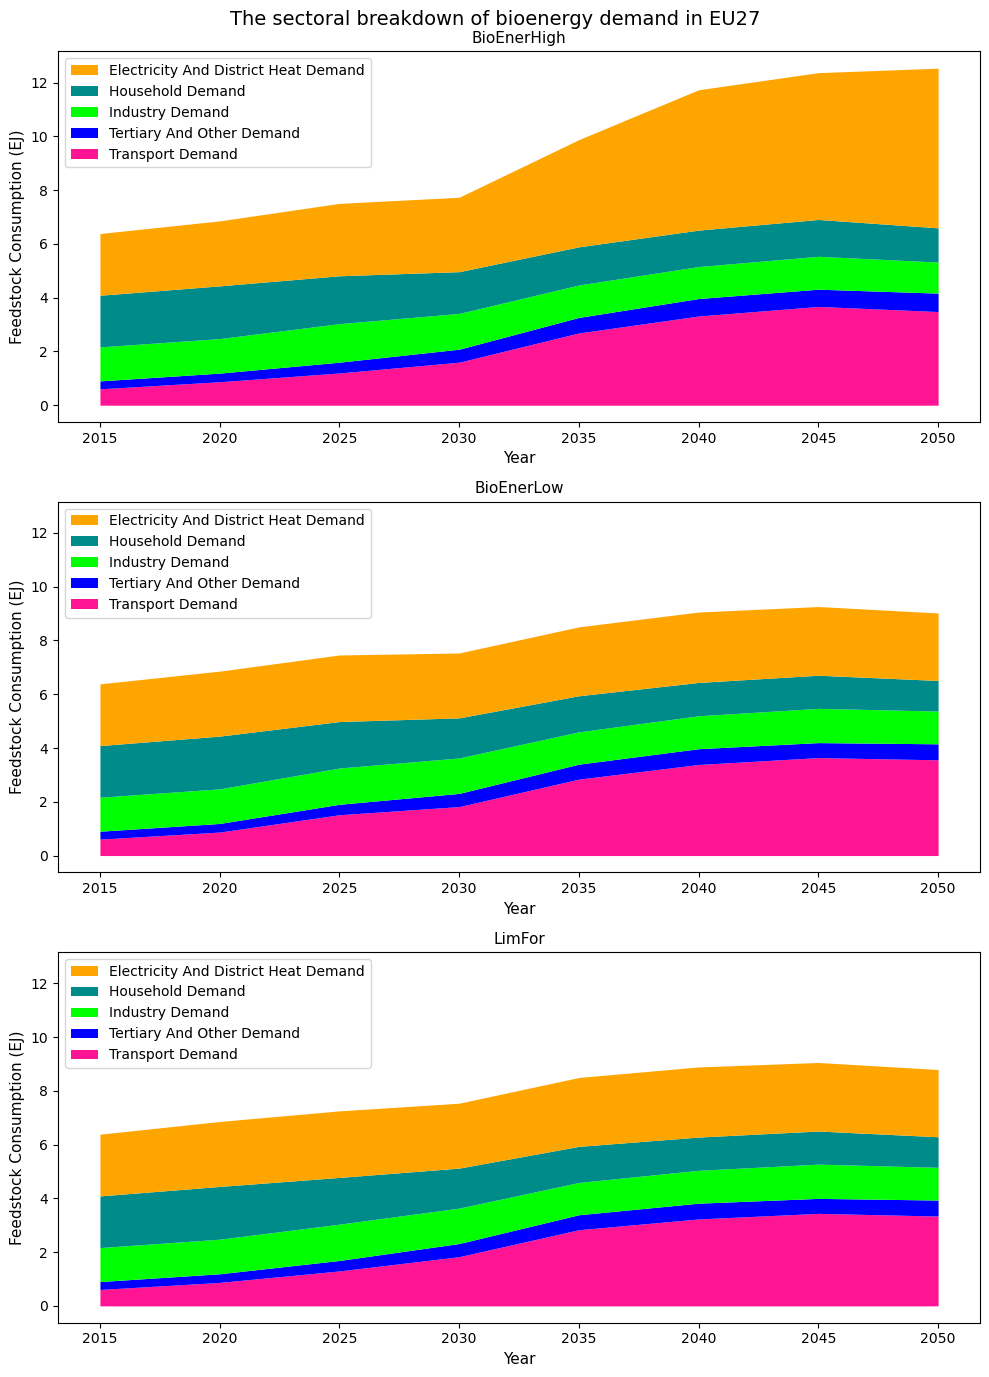

In [22]:
# Configure the color
var_color = {
    "Household Demand" : "#008b8b",
    "Electricity And District Heat Demand" : "#ffa500",
    "Industry Demand" : "#00ff00",
    "Tertiary And Other Demand" : "#0000ff",
    "Transport Demand" : "#ff1493"
}

pyam.run_control()["color"]["variable"] = var_color

fig, axes = plt.subplots(3, 1, figsize=(10, 14), sharey=True)
plt.suptitle("The sectoral breakdown of bioenergy demand in EU27", fontsize=14)

for scene, ax in zip(sectoral_demand.scenario, axes.flat):
    data = master_pyam_complete.filter(
        scenario=scene,
        variable=[
            "Household Demand",
            "Electricity And District Heat Demand",
            "Industry Demand",
            "Tertiary And Other Demand",
            "Transport Demand"
        ],
        region="EU27",
        unit="EJ"
    )

    data.plot.stack(title=scene, ax=ax, legend=False)

    # Set the fontsize for the axis titles
    ax.set(
        ylabel="Feedstock Consumption (EJ)",
        xlabel="Year"
    )

    # Set the fontsize of the axis titles
    ax.yaxis.label.set_size(11)
    ax.xaxis.label.set_size(11)
    ax.title.set_size(11)

    ax.legend(loc="upper left")

plt.tight_layout()
# plt.savefig(f"{out_fig_dir}/stacked_line_sectoral_demand.png", dpi=300)

# Calculating the feedstock supply from different sources (e.g. the supply from food crops, from forestry biomass, etc)

In [23]:
feedstock_origins = [
    "Biomass Of Waste Origin",
    "Food Crops",
    "Forestry Biomass",
    "Imported Oil",
    "Imported Wood",
    "Lignocelluosic Crops & Agricultural Residues",
]

biofuel_type = [
    "All Biofuels", "Gaseous Biofuels",
    "Liquid Biofuels", "Solid Biofuels"
]

pyam_template = []

all_fuels = {}
for fuel in biofuel_type:

    all_origins = {}
    for origin in feedstock_origins:
        sel_pyam = master_pyam_complete.filter(
            variable=f"*{fuel}|{origin}",
        )

        aggregate = sel_pyam.timeseries().groupby(["model", "scenario", "region", "unit"]).sum()

        ix_order = ["model", "scenario", "region", "variable", "unit"]
        all_origins[origin] = assignlevel(
            aggregate,
            variable=f"Feedstock Supply|{fuel}|{origin}"
        ).reorder_levels(ix_order)
    
    all_origins_df = pd.concat(all_origins.values()).sort_index()
    all_fuels[fuel] = all_origins_df

feedstock_supply = pd.concat(all_fuels.values())

# Turn into pyam
feedstock_supply_pyam = pyam.IamDataFrame(feedstock_supply)

In [24]:
# Concat to master dataframe
master_pyam_complete = pyam.concat([master_pyam_complete, feedstock_supply_pyam])

/Users/firzariany/opt/anaconda3/envs/firza_forest_geo/lib/python3.10/site-packages/pyam/plotting.py:466: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  pd.concat([_df, _rows.loc[_rows.index.difference(_df.index)]])
/Users/firzariany/opt/anaconda3/envs/firza_forest_geo/lib/python3.10/site-packages/pyam/plotting.py:466: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  pd.concat([_df, _rows.loc[_rows.index.difference(_df.index)]])
/Users/firzariany/opt/anaconda3/envs/firza_forest_geo/lib/python3.10/site-packages/pyam/plotting.py:466: FutureWarning: The behavior

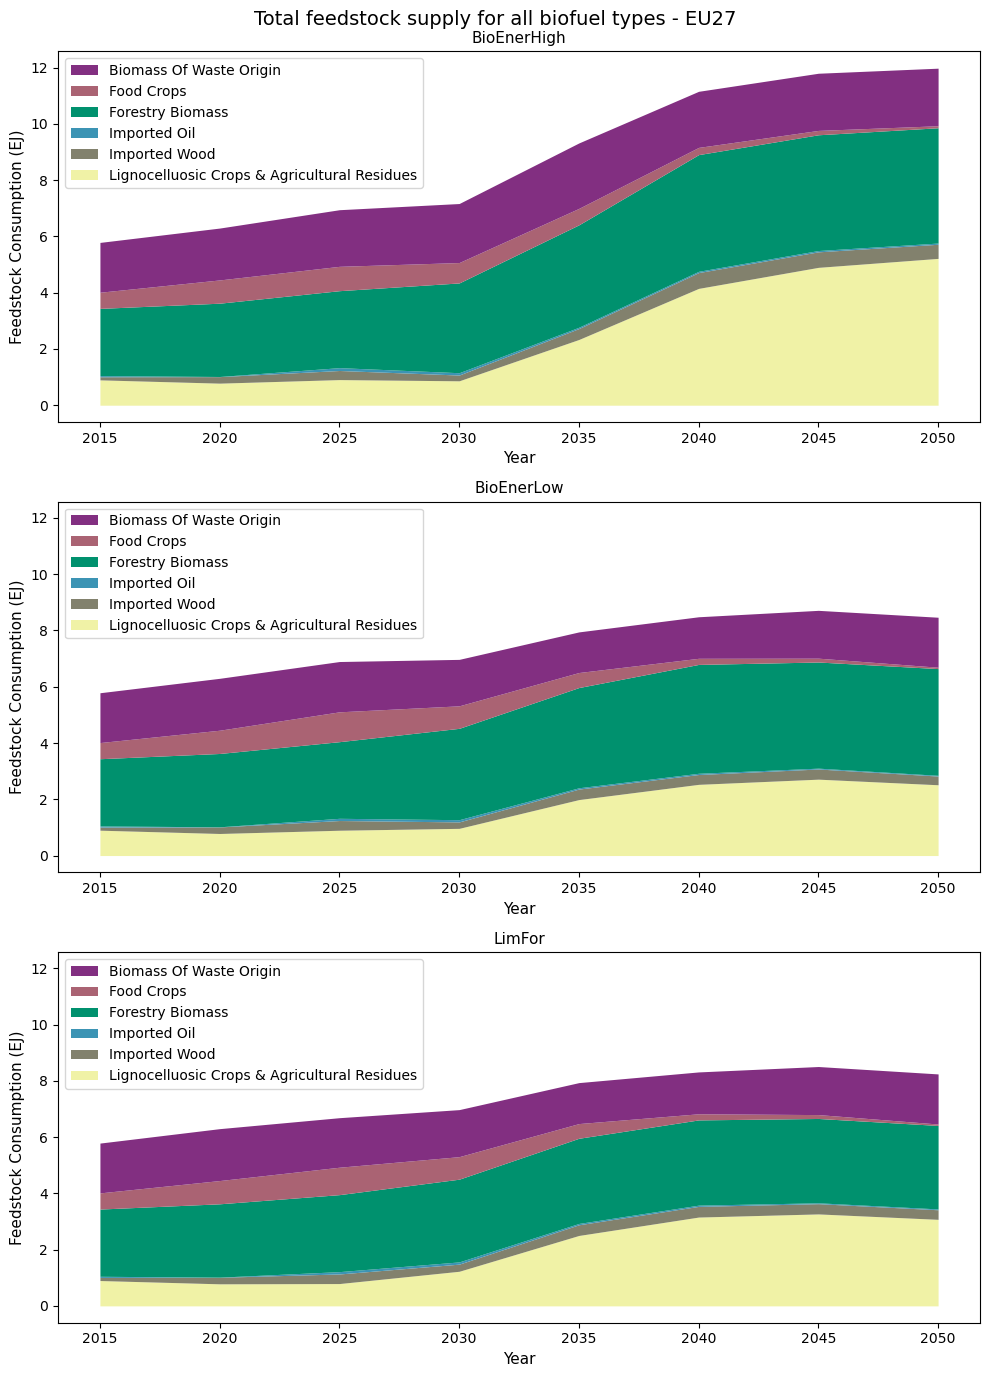

In [25]:
# Configure the color
var_color = {
    "Biomass Of Waste Origin" : "#822f81",
    "Food Crops" : "#aa6373",
    "Forestry Biomass" : "#00916e",
    "Imported Oil" : "#3c94b4",
    "Imported Wood" : "#82816d",
    "Lignocelluosic Crops & Agricultural Residues" : "#f0f2a6"
}

pyam.run_control()["color"]["variable"] = var_color

fig, axes = plt.subplots(3, 1, figsize=(10, 14), sharey=True)
plt.suptitle("Total feedstock supply for all biofuel types - EU27", fontsize=14)

for scene, ax in zip(sectoral_demand.scenario, axes.flat):
    data = feedstock_supply_pyam.filter(
        scenario=scene,
        variable="Feedstock Supply|All Biofuels*",
        region="EU27",
        unit="EJ"
    )
    
    for v in data.variable:
        data.rename(variable={v : v.split("|")[-1]}, inplace=True)

    data.plot.stack(title=scene, ax=ax, legend=False)

    # Set the fontsize for the axis titles
    ax.set(
        ylabel="Feedstock Consumption (EJ)",
        xlabel="Year"
    )

    # Set the fontsize of the axis titles
    ax.yaxis.label.set_size(11)
    ax.xaxis.label.set_size(11)
    ax.title.set_size(11)

    ax.legend(loc="upper left")

plt.tight_layout()
# plt.savefig(f"{out_fig_dir}/stacked_line_sectoral_demand.png", dpi=300)

# Exporting the cleaned dataframe

In [26]:
master_pyam_complete.to_csv("../input_data/master_scenarios_aggregated.csv")

# # Use ExcelWriter to save multiple DataFrames to different sheets
# with pd.ExcelWriter(f"{out_dir}/BioEnerHigh_template_test.xlsx", engine='xlsxwriter') as writer:
#     BioEnerHigh_melt.to_excel(writer, sheet_name='Sheet1', index=False)
#     BioEnerHigh.to_excel(writer, sheet_name='Sheet2', index=False)